In [107]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sys.path.append(str(Path("..").resolve()))

from src.reasoning_compression.features import (
    count_share_table,
    format_metrics_percent,
    latest_feature_build_dir,
    normalize_difficulty,
)

# Full-Scale Modeling and Evaluation

This notebook runs the main modeling workflow on the full locally engineered OpenMementos feature tables.

The primary modeling unit is the block-level table: one row represents one `(reasoning block, summary)` pair. The target is `high_token_compression`, which identifies blocks whose `summary_to_block_token_ratio` is at or below the 25th percentile computed on the persisted training split.

The trace-level table is loaded for coverage checks and trace-level analysis. Both trace-level and block-level models use the persisted `model_split` column created in `01_data_loading_engineering.ipynb`, so all model comparisons use the same held-out traces.

## Data Load and checks

In [108]:
FULL_BUILD_DIR = latest_feature_build_dir(Path("../data/full_feature_builds"))

df_model_blocks = pd.read_parquet(
    FULL_BUILD_DIR / "blocks_features_full_labeled.parquet"
)
df_model_blocks["difficulty"] = df_model_blocks["difficulty"].map(
    normalize_difficulty
)

df_model_traces = pd.read_parquet(
    FULL_BUILD_DIR / "traces_features_full_labeled.parquet"
)
df_model_traces["difficulty"] = df_model_traces["difficulty"].map(
    normalize_difficulty
)

df_model_blocks.shape, df_model_traces.shape

((2013510, 23), (228557, 27))

In [109]:
required_block_columns = {"model_split", "high_token_compression"}
required_trace_columns = {"model_split", "trace_high_token_compression"}
expected_split_labels = {"train", "test"}

missing_block_columns = required_block_columns.difference(df_model_blocks.columns)
missing_trace_columns = required_trace_columns.difference(df_model_traces.columns)

if missing_block_columns:
    raise ValueError(
        "The labeled block parquet is missing columns "
        f"{sorted(missing_block_columns)}. Re-run "
        "01_data_loading_engineering.ipynb from the split/threshold "
        "cells with RUN_FULL_BUILD = False."
    )

if missing_trace_columns:
    raise ValueError(
        "The labeled trace parquet is missing columns "
        f"{sorted(missing_trace_columns)}. Re-run "
        "01_data_loading_engineering.ipynb from the split/threshold "
        "cells with RUN_FULL_BUILD = False."
    )

if df_model_blocks["model_split"].isna().any():
    raise ValueError("Some block rows are missing model_split values.")

if df_model_traces["model_split"].isna().any():
    raise ValueError("Some trace rows are missing model_split values.")

block_split_labels = set(df_model_blocks["model_split"].unique())
trace_split_labels = set(df_model_traces["model_split"].unique())

if block_split_labels != expected_split_labels:
    raise ValueError(
        "Unexpected block split labels: "
        f"expected {sorted(expected_split_labels)}, "
        f"got {sorted(block_split_labels)}."
    )

if trace_split_labels != expected_split_labels:
    raise ValueError(
        "Unexpected trace split labels: "
        f"expected {sorted(expected_split_labels)}, "
        f"got {sorted(trace_split_labels)}."
    )

split_validation = pd.DataFrame({
    "blocks": df_model_blocks["model_split"].value_counts(),
    "traces": df_model_traces["model_split"].value_counts(),
}).reindex(["train", "test"]).fillna(0).astype(int)

split_validation


,blocks,traces
model_split,,
train,1611167,182845
test,402343,45712


In [110]:
df_model_blocks.head(3)

,trace_id,block_index,domain,source,difficulty,problem_chars,problem_tokens,problem_math_symbol_share,problem_has_multiple_choice,problem_has_code_fence,...,block_chars,summary_chars,block_tokens,summary_tokens,summary_to_block_char_ratio,summary_to_block_token_ratio,char_compression_savings,token_compression_savings,model_split,high_token_compression
0,0,0,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,809,319,200,77,0.394314,0.385000,0.605686,0.615000,train,0
1,0,1,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,2608,445,737,111,0.170629,0.150611,0.829371,0.849389,train,0
2,0,2,code,stackexchange_codegolf,7.0,931,227,0.01826,0,0,...,2213,465,654,133,0.210122,0.203364,0.789878,0.796636,train,0


In [111]:
column_names = df_model_blocks.columns.tolist()
print(column_names)

['trace_id', 'block_index', 'domain', 'source', 'difficulty', 'problem_chars', 'problem_tokens', 'problem_math_symbol_share', 'problem_has_multiple_choice', 'problem_has_code_fence', 'problem_question_mark_count', 'n_blocks_in_trace', 'relative_block_position', 'block_chars', 'summary_chars', 'block_tokens', 'summary_tokens', 'summary_to_block_char_ratio', 'summary_to_block_token_ratio', 'char_compression_savings', 'token_compression_savings', 'model_split', 'high_token_compression']


In [112]:
# Keep this notebook reproducible from local feature parquet files only.
# Raw response previews from exploratory notebooks are intentionally not loaded
# through IPython storage.
df_model_blocks.query("trace_id == 1").sort_values("block_index")[[
    "trace_id",
    "block_index",
    "domain",
    "source",
    "difficulty",
    "block_tokens",
    "summary_tokens",
    "summary_to_block_token_ratio",
]].head()

,trace_id,block_index,domain,source,difficulty,block_tokens,summary_tokens,summary_to_block_token_ratio
7,1,0,code,stackexchange_codegolf,7.0,256,57,0.222656
8,1,1,code,stackexchange_codegolf,7.0,251,45,0.179283
9,1,2,code,stackexchange_codegolf,7.0,267,75,0.280899
10,1,3,code,stackexchange_codegolf,7.0,258,157,0.608527
11,1,4,code,stackexchange_codegolf,7.0,353,135,0.382436


In [113]:
df_model_blocks.query("trace_id == 1").sort_values("block_index")[[
    "trace_id",
    "block_index",
    "block_tokens",
    "summary_tokens",
    "summary_to_block_token_ratio",
    "token_compression_savings",
    "high_token_compression",
    "model_split",
]]

,trace_id,block_index,block_tokens,summary_tokens,summary_to_block_token_ratio,token_compression_savings,high_token_compression,model_split
7,1,0,256,57,0.222656,0.777344,0,train
8,1,1,251,45,0.179283,0.820717,0,train
9,1,2,267,75,0.280899,0.719101,0,train
10,1,3,258,157,0.608527,0.391473,0,train
11,1,4,353,135,0.382436,0.617564,0,train
12,1,5,261,58,0.222222,0.777778,0,train
13,1,6,223,58,0.260090,0.739910,0,train
14,1,7,241,127,0.526971,0.473029,0,train


In [114]:
df_model_traces.iloc[[1]][[
    "trace_id",
    "domain",
    "source",
    "difficulty",
    "problem_tokens",
    "n_blocks",
    "n_summaries",
    "trace_block_tokens",
    "trace_summary_tokens",
    "trace_total_summary_to_block_token_ratio",
    "trace_high_token_compression",
    "model_split",
]]

,trace_id,domain,source,difficulty,problem_tokens,n_blocks,n_summaries,trace_block_tokens,trace_summary_tokens,trace_total_summary_to_block_token_ratio,trace_high_token_compression,model_split
1,1,code,stackexchange_codegolf,7.0,148,8,8,2110,712,0.337441,0,train


### Categorical values

In [115]:
count_share_table(df_model_traces, "domain")

,n_rows,share_pct
domain,,
math,123333,53.96
science,61485,26.90
code,43739,19.14


In [116]:
count_share_table(df_model_traces, "source")

,n_rows,share_pct
source,,
ai2-adapt-dev/openmath-2-math,123333,53.96
organic-chemistry-questions,39097,17.11
nvidia/OpenCodeReasoning,25155,11.01
stackexchange-physics,22388,9.80
stackexchange_codegolf,18584,8.13


In [117]:
count_share_table(df_model_blocks, "domain")

,n_rows,share_pct
domain,,
math,1168291,58.02
science,430606,21.39
code,414613,20.59


In [118]:
count_share_table(df_model_blocks, "source")

,n_rows,share_pct
source,,
ai2-adapt-dev/openmath-2-math,1168291,58.02
organic-chemistry-questions,259832,12.90
nvidia/OpenCodeReasoning,236788,11.76
stackexchange_codegolf,177825,8.83
stackexchange-physics,170774,8.48


### Target Distribution

The block-level target `high_token_compression` is defined from the training split distribution of `summary_to_block_token_ratio` and then applied to both training and test rows.

The training split should therefore have approximately 25% high-compression rows. The test split may differ slightly because it is held out by trace.

In [119]:
target_distribution_by_split = (
    df_model_blocks
    .groupby("model_split")["high_token_compression"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .assign(share_pct=lambda df: (df["share"] * 100).round(2))
    .drop(columns="share")
)

target_distribution_by_split

,model_split,high_token_compression,share_pct
0,test,0,75.03
1,test,1,24.97
2,train,0,75.00
3,train,1,25.00


In [120]:
summary = df_model_blocks["summary_to_block_token_ratio"].describe()

summary_display = summary.copy().astype(object)
summary_display["count"] = f"{int(summary['count']):,}"

for idx in summary.index.drop("count"):
    summary_display[idx] = f"{summary[idx]:.4f}"

summary_display

count    2,013,510
mean        0.2154
std         0.1476
min         0.0005
25%         0.1089
50%         0.1778
75%         0.2817
max         2.7774
Name: summary_to_block_token_ratio, dtype: object

# Modeling Features

The main full-scale models use block-level, trace-position, prompt-level, and metadata features.

The target-defining variables are excluded from the input features to avoid leakage. In particular, `summary_tokens`, `summary_to_block_token_ratio`, and `token_compression_savings` are outcomes, not predictors.

In [121]:
TARGET = "high_token_compression"
GROUP_COL = "trace_id"
SPLIT_COL = "model_split"

numeric_features = [
    "block_index",
    "relative_block_position",
    "n_blocks_in_trace",
    "problem_chars",
    "problem_tokens",
    "problem_math_symbol_share",
    "problem_question_mark_count",
    "block_tokens",
]

binary_features = [
    "problem_has_multiple_choice",
    "problem_has_code_fence",
]

categorical_features = [
    "domain",
    "source",
    "difficulty",
]

feature_columns = numeric_features + binary_features + categorical_features

In [122]:
# Keep only model inputs, target, trace grouping column, and persisted split.
df_model_1 = df_model_blocks[
    feature_columns + [TARGET, GROUP_COL, SPLIT_COL]
].dropna().copy()

X = df_model_1[feature_columns]
y = df_model_1[TARGET]
groups = df_model_1[GROUP_COL]
model_split = df_model_1[SPLIT_COL]

df_model_1.shape

(2013510, 16)

## Persisted Grouped Train/Test Split

The train/test split is loaded from `model_split`, which is created in `01_data_loading_engineering.ipynb` at the trace level and then attached to every block row.

This preserves a single held-out set of traces across notebooks and prevents target-threshold leakage, because `high_token_compression` was computed using the training split threshold.

In [123]:
train_mask = model_split == "train"
test_mask = model_split == "test"

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]
groups_train = groups.loc[train_mask]
groups_test = groups.loc[test_mask]

X_train.shape, X_test.shape

((1611167, 13), (402343, 13))

In [124]:
# No trace overlap between train and test.
len(set(groups_train).intersection(set(groups_test)))

0

In [125]:
# Class balance from the persisted split.
pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).round(4)

,train,test
high_token_compression,,
0,0.75,0.7503
1,0.25,0.2497


## Evaluation Helper

This helper evaluates fitted classifiers using the same metrics across models.

In [126]:
def evaluate_classifier(model, X_test, y_test) -> dict:
    # Predict class labels and class-1 probabilities for threshold-based and
    # ranking-based evaluation.
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
    }

## Dummy Baseline

The dummy classifier predicts the majority class. It establishes the no-skill reference point for the full-data task.

In [127]:
dummy_model = Pipeline(
    steps=[
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_metrics = {
    "accuracy": accuracy_score(y_test, dummy_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, dummy_pred),
    "roc_auc": np.nan,
}

format_metrics_percent(dummy_metrics)

,metric,value
0,accuracy,75.03%
1,balanced_accuracy,50.00%
2,roc_auc,nan%


## Logistic Regression Reference

Logistic regression is included as an interpretable reference model, not as the main modeling approach.

Numeric features are standardized, binary features are passed through (no transformations), and categorical features are one-hot encoded.

In [128]:
linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

logit_model = Pipeline(
    steps=[
        ("preprocess", linear_preprocess),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

logit_model.fit(X_train, y_train)

logit_metrics = evaluate_classifier(logit_model, X_test, y_test)

format_metrics_percent(logit_metrics)

,metric,value
0,accuracy,73.28%
1,balanced_accuracy,71.86%
2,roc_auc,79.70%


# Random Forest

Random forests are one of the core modeling approaches for this project. They can capture nonlinear relationships and interactions between prompt features, block position, trace structure, and metadata.

Numeric features are passed through unchanged because tree-based models do not require standardization. Categorical features are one-hot encoded.

In [129]:
tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [130]:
## # num estimators optimizer
## n_estimators_grid = [100, 200, 300, 800]
## 
## rf_estimator_results = []
## 
## for n_estimators in n_estimators_grid:
##     # Keep all other hyperparameters fixed so this experiment isolates the
##     # effect of forest size.
##     rf_candidate = Pipeline(
##         steps=[
##             ("preprocess", tree_preprocess),
##             ("model", RandomForestClassifier(
##                 n_estimators=n_estimators,
##                 max_depth=None,
##                 min_samples_leaf=5,
##                 class_weight="balanced",
##                 random_state=42,
##                 n_jobs=-1,
##             )),
##         ]
##     )
## 
##     rf_candidate.fit(X_train, y_train)
## 
##     candidate_proba = rf_candidate.predict_proba(X_test)[:, 1]
##     candidate_pred = rf_candidate.predict(X_test)
## 
##     rf_estimator_results.append({
##         "n_estimators": n_estimators,
##         "accuracy": accuracy_score(y_test, candidate_pred),
##         "balanced_accuracy": balanced_accuracy_score(y_test, candidate_pred),
##         "roc_auc": roc_auc_score(y_test, candidate_proba),
##     })
## 
## rf_estimator_results = pd.DataFrame(rf_estimator_results)
## rf_estimator_results

The first two random-forest runs below are intentionally kept as an audit trail. They were part of the initial implementation that used the held-out test set as if it were a validation set for hyperparameter exploration. That is not valid for model selection because the final test performance is no longer independent.

They are therefore treated as diagnostic comparison runs, not as the model-selection basis. The corrected implementation appears afterward: tune on an inner grouped validation split, refit the selected model on the full training split, and evaluate it once on the held-out grouped test split.

In [131]:
# Earlier diagnostic run: 300 estimators with class_weight="balanced_subsample".
# This configuration was evaluated during the original test-set-based RF exploration.
rf_test_tuned_subsample_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_test_tuned_subsample_model.fit(X_train, y_train)

rf_test_tuned_subsample_metrics = evaluate_classifier(
    rf_test_tuned_subsample_model,
    X_test,
    y_test,
)
rf_test_tuned_subsample_pred = rf_test_tuned_subsample_model.predict(X_test)
rf_test_tuned_subsample_confusion_matrix = confusion_matrix(
    y_test,
    rf_test_tuned_subsample_pred,
)
rf_test_tuned_subsample_feature_names = (
    rf_test_tuned_subsample_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)
rf_test_tuned_subsample_importance_table = (
    pd.DataFrame({
        "feature": rf_test_tuned_subsample_feature_names,
        "importance": rf_test_tuned_subsample_model.named_steps["model"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

format_metrics_percent(rf_test_tuned_subsample_metrics)

,metric,value
0,accuracy,75.48%
1,balanced_accuracy,71.59%
2,roc_auc,80.38%


In [132]:
# Earlier diagnostic run: 300 estimators with class_weight="balanced".
# This configuration was also evaluated during the original test-set-based RF exploration.
rf_test_tuned_balanced_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_test_tuned_balanced_model.fit(X_train, y_train)

rf_test_tuned_balanced_metrics = evaluate_classifier(
    rf_test_tuned_balanced_model,
    X_test,
    y_test,
)

format_metrics_percent(rf_test_tuned_balanced_metrics)

,metric,value
0,accuracy,73.65%
1,balanced_accuracy,72.21%
2,roc_auc,80.41%


In [133]:
rf_test_tuned_balanced_pred = rf_test_tuned_balanced_model.predict(X_test)

print(classification_report(y_test, rf_test_tuned_balanced_pred))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81    301862
           1       0.48      0.69      0.57    100481

    accuracy                           0.74    402343
   macro avg       0.68      0.72      0.69    402343
weighted avg       0.78      0.74      0.75    402343



In [134]:
rf_test_tuned_balanced_confusion_matrix = confusion_matrix(
    y_test,
    rf_test_tuned_balanced_pred,
)

rf_test_tuned_balanced_confusion_matrix

array([[226648,  75214],
       [ 30803,  69678]])

In [135]:
rf_test_tuned_balanced_feature_names = (
    rf_test_tuned_balanced_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

rf_test_tuned_balanced_importance_table = (
    pd.DataFrame({
        "feature": rf_test_tuned_balanced_feature_names,
        "importance": rf_test_tuned_balanced_model.named_steps["model"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

rf_test_tuned_balanced_importance_table.head(30).round(4)

,feature,importance
7,num__block_tokens,0.5150
3,num__problem_chars,0.0966
5,num__problem_math_symbol_share,0.0889
4,num__problem_tokens,0.0877
0,num__block_index,0.0534
1,num__relative_block_position,0.0531
2,num__n_blocks_in_trace,0.0515
6,num__problem_question_mark_count,0.0123
12,cat__domain_science,0.0113
11,cat__domain_math,0.0061


In the initial implementation, `X_test` and `y_test` were used to compare random-forest hyperparameter choices and then to report the selected model. This turns the test set into a validation set. The runs above remain useful as a learning artifact, but they should not determine the final random-forest configuration.

In [136]:
rf_selection_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43,
)

rf_fit_idx, rf_val_idx = next(
    rf_selection_splitter.split(X_train, y_train, groups=groups_train)
)

X_rf_fit = X_train.iloc[rf_fit_idx]
X_rf_val = X_train.iloc[rf_val_idx]
y_rf_fit = y_train.iloc[rf_fit_idx]
y_rf_val = y_train.iloc[rf_val_idx]


In [137]:
# Tune only on the inner validation split.
rf_param_grid = [
    {"n_estimators": n_estimators, "class_weight": class_weight}
    for n_estimators in [50, 100, 150]
    for class_weight in ["balanced", "balanced_subsample"]
]

rf_selection_results = []

for params in rf_param_grid:
    rf_candidate = Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", RandomForestClassifier(
                n_estimators=params["n_estimators"],
                max_depth=None,
                min_samples_leaf=5,
                class_weight=params["class_weight"],
                random_state=42,
                n_jobs=-1,
            )),
        ]
    )

    rf_candidate.fit(X_rf_fit, y_rf_fit)
    validation_metrics = evaluate_classifier(rf_candidate, X_rf_val, y_rf_val)

    rf_selection_results.append({
        **params,
        **validation_metrics,
    })

rf_selection_results = (
    pd.DataFrame(rf_selection_results)
    .sort_values(["roc_auc", "balanced_accuracy"], ascending=False)
)

rf_selection_results

,n_estimators,class_weight,accuracy,balanced_accuracy,roc_auc
4,150,balanced,0.734423,0.719450,0.801421
5,150,balanced_subsample,0.753195,0.713236,0.801253
3,100,balanced_subsample,0.753000,0.713177,0.800981
2,100,balanced,0.734212,0.719522,0.800931
0,50,balanced,0.732538,0.718429,0.799865
1,50,balanced_subsample,0.751158,0.712551,0.799687


Random forest hyperparameters were selected on an inner grouped validation split, not on the held-out test split. Among the tested settings, `n_estimators=150` and `class_weight="balanced"` achieved the best validation ROC AUC and balanced accuracy. We use this configuration for the final RF model and evaluate it once on the grouped test split.

In [138]:
rf_validation_tuned_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_validation_tuned_model.fit(X_train, y_train)

rf_validation_tuned_metrics = evaluate_classifier(
    rf_validation_tuned_model,
    X_test,
    y_test,
)

format_metrics_percent(rf_validation_tuned_metrics)

,metric,value
0,accuracy,73.65%
1,balanced_accuracy,72.22%
2,roc_auc,80.37%


In [139]:
rf_validation_tuned_pred = rf_validation_tuned_model.predict(X_test)

print(classification_report(y_test, rf_validation_tuned_pred))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81    301862
           1       0.48      0.69      0.57    100481

    accuracy                           0.74    402343
   macro avg       0.68      0.72      0.69    402343
weighted avg       0.78      0.74      0.75    402343



In this report class 1 means a block is in the highly compressed group, while class 0 means it is not
support is the number of true examples in each class

The tuned random forest shows useful predictive signal for block-level high token compression. It performs best on the majority non-high-compression class, with high precision and a strong F1-score. For the high-compression class, recall is relatively good: the model identifies around 69% of truly high-compression blocks. However, precision is lower, meaning the model over-predicts high compression and produces a substantial number of false positives. This tradeoff is consistent with using class balancing: the model is encouraged to detect the minority class, even at the cost of lower raw accuracy and lower precision. Overall, the model appears useful for flagging likely high-compression blocks, but its positive predictions should be interpreted as candidates rather than certain classifications.

`class_weight="balanced"` and `class_weight="balanced_subsample"` are both designed to reduce the effect of class imbalance in random forests. In this task, the positive class, `high_token_compression`, is the minority class, so an unweighted model could achieve reasonable raw accuracy by mostly predicting the majority class.

With `class_weight="balanced"`, scikit-learn computes one set of class weights from the full training data. Minority-class observations receive higher weight, so errors on high-compression blocks contribute more strongly to the tree-splitting objective.

With `class_weight="balanced_subsample"`, the same idea is applied separately inside each bootstrap sample used to train each tree. This means class weights can vary from tree to tree depending on the class composition of that tree's sampled data.

In these results, `balanced` performs better than `balanced_subsample` on the preferred imbalance-aware metrics. A plausible explanation is that the overall training distribution is already large and stable, so a single global class-weight correction is sufficient. Recomputing weights within each bootstrap sample may add unnecessary variability across trees, making the ensemble slightly less stable or more conservative in detecting the minority high-compression class. Since the goal is to identify both classes fairly, balanced accuracy and ROC AUC are more informative than raw accuracy when comparing these settings.

In [140]:
rf_validation_tuned_confusion_matrix = confusion_matrix(
    y_test,
    rf_validation_tuned_pred,
)

rf_validation_tuned_confusion_matrix

array([[226616,  75246],
       [ 30786,  69695]])

In [141]:
rf_validation_tuned_feature_names = (
    rf_validation_tuned_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

rf_validation_tuned_importance_table = (
    pd.DataFrame({
        "feature": rf_validation_tuned_feature_names,
        "importance": rf_validation_tuned_model.named_steps["model"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

rf_validation_tuned_importance_table.head(30).round(4)

,feature,importance
7,num__block_tokens,0.5130
3,num__problem_chars,0.0969
5,num__problem_math_symbol_share,0.0890
4,num__problem_tokens,0.0879
0,num__block_index,0.0557
1,num__relative_block_position,0.0521
2,num__n_blocks_in_trace,0.0514
6,num__problem_question_mark_count,0.0122
12,cat__domain_science,0.0117
11,cat__domain_math,0.0067


## Random Forest Run Comparison

The table below compares the two earlier test-tuned random-forest runs with the corrected validation-tuned run. The earlier runs are retained to make the modeling mistake visible: they used the held-out test set during hyperparameter exploration. The validation-tuned run is the one to use for downstream model comparison.

In [142]:
rf_run_specs = [
    {
        "run": "test_tuned_300_balanced_subsample",
        "selection_basis": "test set, kept as diagnostic",
        "n_estimators": 300,
        "class_weight": "balanced_subsample",
        "model": rf_test_tuned_subsample_model,
        "metrics": rf_test_tuned_subsample_metrics,
        "pred": rf_test_tuned_subsample_pred,
        "confusion_matrix": rf_test_tuned_subsample_confusion_matrix,
        "importance_table": rf_test_tuned_subsample_importance_table,
    },
    {
        "run": "test_tuned_300_balanced",
        "selection_basis": "test set, kept as diagnostic",
        "n_estimators": 300,
        "class_weight": "balanced",
        "model": rf_test_tuned_balanced_model,
        "metrics": rf_test_tuned_balanced_metrics,
        "pred": rf_test_tuned_balanced_pred,
        "confusion_matrix": rf_test_tuned_balanced_confusion_matrix,
        "importance_table": rf_test_tuned_balanced_importance_table,
    },
    {
        "run": "validation_tuned_150_balanced",
        "selection_basis": "inner grouped validation split",
        "n_estimators": 150,
        "class_weight": "balanced",
        "model": rf_validation_tuned_model,
        "metrics": rf_validation_tuned_metrics,
        "pred": rf_validation_tuned_pred,
        "confusion_matrix": rf_validation_tuned_confusion_matrix,
        "importance_table": rf_validation_tuned_importance_table,
    },
]

rf_run_metrics_comparison = pd.DataFrame([
    {
        "run": run_spec["run"],
        "selection_basis": run_spec["selection_basis"],
        "n_estimators": run_spec["n_estimators"],
        "class_weight": run_spec["class_weight"],
        **run_spec["metrics"],
    }
    for run_spec in rf_run_specs
])

rf_run_metrics_display = rf_run_metrics_comparison.copy()
for metric in ["accuracy", "balanced_accuracy", "roc_auc"]:
    rf_run_metrics_display[metric] = (
        rf_run_metrics_display[metric] * 100
    ).round(2)

rf_run_metrics_display

,run,selection_basis,n_estimators,class_weight,accuracy,balanced_accuracy,roc_auc
0,test_tuned_300_balanced_subsample,"test set, kept as diagnostic",300,balanced_subsample,75.48,71.59,80.38
1,test_tuned_300_balanced,"test set, kept as diagnostic",300,balanced,73.65,72.21,80.41
2,validation_tuned_150_balanced,inner grouped validation split,150,balanced,73.65,72.22,80.37


In [143]:
def make_classification_report_frame(
    run_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    rows = []
    for label, values in report.items():
        if isinstance(values, dict):
            rows.append({"run": run_name, "label": label, **values})
        else:
            rows.append({
                "run": run_name,
                "label": label,
                "precision": np.nan,
                "recall": np.nan,
                "f1-score": values,
                "support": len(y_true),
            })

    return pd.DataFrame(rows)


rf_classification_report_comparison = pd.concat(
    [
        make_classification_report_frame(
            run_name=run_spec["run"],
            y_true=y_test,
            y_pred=run_spec["pred"],
        )
        for run_spec in rf_run_specs
    ],
    ignore_index=True,
)

rf_classification_report_comparison.round(4)

,run,label,precision,recall,f1-score,support
0,test_tuned_300_balanced_subsample,0,0.8682,0.7937,0.8293,301862.0
1,test_tuned_300_balanced_subsample,1,0.5072,0.6381,0.5652,100481.0
2,test_tuned_300_balanced_subsample,accuracy,NaN,NaN,0.7548,402343.0
3,test_tuned_300_balanced_subsample,macro avg,0.6877,0.7159,0.6972,402343.0
4,test_tuned_300_balanced_subsample,weighted avg,0.7781,0.7548,0.7633,402343.0
5,test_tuned_300_balanced,0,0.8804,0.7508,0.8105,301862.0
6,test_tuned_300_balanced,1,0.4809,0.6934,0.5679,100481.0
7,test_tuned_300_balanced,accuracy,NaN,NaN,0.7365,402343.0
8,test_tuned_300_balanced,macro avg,0.6806,0.7221,0.6892,402343.0
9,test_tuned_300_balanced,weighted avg,0.7806,0.7365,0.7499,402343.0


In [144]:
rf_confusion_matrix_comparison = pd.DataFrame([
    {
        "run": run_spec["run"],
        "true_negative": run_spec["confusion_matrix"][0, 0],
        "false_positive": run_spec["confusion_matrix"][0, 1],
        "false_negative": run_spec["confusion_matrix"][1, 0],
        "true_positive": run_spec["confusion_matrix"][1, 1],
    }
    for run_spec in rf_run_specs
])

rf_confusion_matrix_comparison

,run,true_negative,false_positive,false_negative,true_positive
0,test_tuned_300_balanced_subsample,239574,62288,36367,64114
1,test_tuned_300_balanced,226648,75214,30803,69678
2,validation_tuned_150_balanced,226616,75246,30786,69695


In [145]:
rf_feature_importance_comparison = pd.concat(
    [
        run_spec["importance_table"]
        .assign(run=run_spec["run"])
        .loc[:, ["run", "feature", "importance"]]
        for run_spec in rf_run_specs
    ],
    ignore_index=True,
)

rf_feature_importance_wide = (
    rf_feature_importance_comparison
    .pivot(index="feature", columns="run", values="importance")
    .fillna(0)
)

rf_feature_importance_wide = (
    rf_feature_importance_wide
    .assign(max_importance=lambda df: df.max(axis=1))
    .sort_values("max_importance", ascending=False)
    .drop(columns="max_importance")
)

rf_feature_importance_wide.head(30).round(4)

run,test_tuned_300_balanced,test_tuned_300_balanced_subsample,validation_tuned_150_balanced
feature,,,
num__block_tokens,0.5150,0.5000,0.5130
num__problem_chars,0.0966,0.1024,0.0969
num__problem_math_symbol_share,0.0889,0.0940,0.0890
num__problem_tokens,0.0877,0.0931,0.0879
num__block_index,0.0534,0.0535,0.0557
num__relative_block_position,0.0531,0.0532,0.0521
num__n_blocks_in_trace,0.0515,0.0509,0.0514
num__problem_question_mark_count,0.0123,0.0125,0.0122
cat__domain_science,0.0113,0.0109,0.0117


### Random Forest Comparison Interpretation

The corrected validation-tuned random forest uses `n_estimators=150` and `class_weight="balanced"`, selected on the inner grouped validation split. Its test performance is very close to the earlier 300-estimator balanced run, which is useful: fixing the selection protocol changes the evidential status of the result more than the substantive conclusion.

The `balanced_subsample` diagnostic run has higher raw accuracy because it predicts the majority class more conservatively, but its balanced accuracy is lower. Since the high-compression class is substantively important and the target is imbalanced, balanced accuracy and ROC AUC remain the right selection criteria.

The feature-importance comparison should also be read as a stability check. If the same dominant features appear across all three RF runs, the model story is less sensitive to the original tuning mistake. For downstream comparisons, use only `rf_validation_tuned_metrics` and `rf_validation_tuned_model`.

# Gradient Boosting

Gradient boosting is the second core modeling approach. It builds trees sequentially, with each new tree improving on the errors of the previous ensemble.

This model tests whether boosted trees improve full-scale compressibility prediction relative to the random forest.

In [146]:
gb_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocess),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

gb_model.fit(X_train, y_train)

gb_metrics = evaluate_classifier(gb_model, X_test, y_test)

format_metrics_percent(gb_metrics)

,metric,value
0,accuracy,71.86%
1,balanced_accuracy,72.73%
2,roc_auc,80.92%


In [147]:
gb_pred = gb_model.predict(X_test)

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.89      0.71      0.79    301862
           1       0.46      0.74      0.57    100481

    accuracy                           0.72    402343
   macro avg       0.68      0.73      0.68    402343
weighted avg       0.79      0.72      0.74    402343



In [148]:
confusion_matrix(y_test, gb_pred)

array([[214288,  87574],
       [ 25651,  74830]])

## Model Comparison

This table compares all full-scale models on the same grouped train/test split.

Balanced accuracy and ROC AUC are the main metrics because the target is imbalanced.

In [149]:
model_comparison = pd.DataFrame([
    {"model": "dummy", **dummy_metrics},
    {"model": "logistic_regression", **logit_metrics},
    {"model": "random_forest_validation_tuned", **rf_validation_tuned_metrics},
    {"model": "gradient_boosting", **gb_metrics},
])

model_comparison_percent = model_comparison.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    model_comparison_percent[col] = (
        model_comparison_percent[col] * 100
    ).round(2)

model_comparison_percent

,model,accuracy,balanced_accuracy,roc_auc
0,dummy,75.03,50.00,NaN
1,logistic_regression,73.28,71.86,79.70
2,random_forest_validation_tuned,73.65,72.22,80.37
3,gradient_boosting,71.86,72.73,80.92


## Full-Scale Model Comparison

On the full block-level dataset, all learned models outperform the dummy baseline on balanced accuracy and ROC AUC.

The dummy classifier reaches high raw accuracy because the target is imbalanced, but its balanced accuracy is 50%, indicating no useful discrimination between high-compression and non-high-compression blocks.

The logistic regression, validation-tuned random forest, and gradient boosting models all reach balanced accuracy around 72% and ROC AUC around 80%. This suggests that the current feature set contains stable predictive signal for block-level compressibility.

Gradient boosting has the strongest performance in this run on balanced accuracy and ROC AUC. The validation-tuned random forest remains close, and logistic regression remains competitive, which suggests that some of the predictive structure is captured by relatively simple relationships, especially block length and trace-position features.

Overall, the full-scale results support the baseline finding that block compressibility is predictable from block-level, prompt-level, trace-position, and metadata features. Random-forest results should now be read from the validation-tuned run rather than from the earlier test-tuned diagnostics.

# Trace-Level Compression Modeling

This section switches from block-level prediction to trace-level prediction.

The modeling unit is now one full reasoning trace. The target is `trace_high_token_compression`, which identifies traces whose total summary-to-block token ratio is at or below the 25th percentile computed on the persisted training split.

In this first trace-level experiment, we use only problem-derived features and metadata. This asks whether the compressibility of an entire reasoning trace can be predicted before observing any generated reasoning blocks.

## Trace-Level Modeling Features

The predictors in this section are restricted to features available from the original problem and dataset metadata.

We intentionally exclude response-derived variables such as `n_blocks`, `think_tokens`, `answer_tokens`, and trace compression ratios because those are only available after generation and would leak information about the target.

In [150]:
TRACE_TARGET = "trace_high_token_compression"

trace_numeric_features = [
    "problem_chars",
    "problem_tokens",
    "problem_math_symbol_share",
    "problem_question_mark_count",
]

trace_binary_features = [
    "problem_has_multiple_choice",
    "problem_has_code_fence",
]

trace_categorical_features = [
    "domain",
    "source",
    "difficulty",
]

trace_feature_columns = (
    trace_numeric_features
    + trace_binary_features
    + trace_categorical_features
)

In [151]:
# Build one model-ready row per reasoning trace.
df_model_traces_1 = df_model_traces[
    trace_feature_columns + [TRACE_TARGET, SPLIT_COL]
].dropna().copy()

X_trace = df_model_traces_1[trace_feature_columns]
y_trace = df_model_traces_1[TRACE_TARGET]
trace_model_split = df_model_traces_1[SPLIT_COL]

df_model_traces_1.shape

(228557, 11)

In [152]:
count_share_table(df_model_traces_1, TRACE_TARGET)

,n_rows,share_pct
trace_high_token_compression,,
0,171471,75.02
1,57086,24.98


## Trace-Level Train/Test Split

Trace-level modeling also uses the persisted `model_split` column. This keeps the trace-level task aligned with the block-level held-out traces.

In [153]:
trace_train_mask = trace_model_split == "train"
trace_test_mask = trace_model_split == "test"

X_trace_train = X_trace.loc[trace_train_mask]
X_trace_test = X_trace.loc[trace_test_mask]
y_trace_train = y_trace.loc[trace_train_mask]
y_trace_test = y_trace.loc[trace_test_mask]

X_trace_train.shape, X_trace_test.shape

((182845, 9), (45712, 9))

In [154]:
pd.DataFrame({
    "train": y_trace_train.value_counts(normalize=True).sort_index(),
    "test": y_trace_test.value_counts(normalize=True).sort_index(),
}).round(4)

,train,test
trace_high_token_compression,,
0,0.75,0.7512
1,0.25,0.2488


## Trace-Level Preprocessing

We reuse the same preprocessing logic as before.

For logistic regression, numeric features are standardized. For tree-based models, numeric and binary features are passed through unchanged, while categorical features are one-hot encoded.

In [155]:
trace_linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), trace_numeric_features),
        ("bin", "passthrough", trace_binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), trace_categorical_features),
    ]
)

trace_tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", trace_numeric_features),
        ("bin", "passthrough", trace_binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), trace_categorical_features),
    ]
)

In [156]:
## Trace-Level Dummy Baseline

## The dummy classifier provides the no-skill baseline for trace-level compression prediction.

trace_dummy_model = Pipeline(
    steps=[
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

trace_dummy_model.fit(X_trace_train, y_trace_train)

trace_dummy_pred = trace_dummy_model.predict(X_trace_test)

trace_dummy_metrics = {
    "accuracy": accuracy_score(y_trace_test, trace_dummy_pred),
    "balanced_accuracy": balanced_accuracy_score(y_trace_test, trace_dummy_pred),
    "roc_auc": np.nan,
}

format_metrics_percent(trace_dummy_metrics)

,metric,value
0,accuracy,75.12%
1,balanced_accuracy,50.00%
2,roc_auc,nan%


In [157]:
## Trace-Level Logistic Regression

## Logistic regression is included as an interpretable linear baseline 
## for predicting trace-level compressibility from problem features.

trace_logit_model = Pipeline(
    steps=[
        ("preprocess", trace_linear_preprocess),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

trace_logit_model.fit(X_trace_train, y_trace_train)

trace_logit_metrics = evaluate_classifier(
    trace_logit_model,
    X_trace_test,
    y_trace_test,
)

format_metrics_percent(trace_logit_metrics)

,metric,value
0,accuracy,51.72%
1,balanced_accuracy,58.37%
2,roc_auc,59.46%


In [158]:
## Trace-Level Random Forest

## The random forest tests whether nonlinear relationships between problem 
## features and metadata improve trace-level compression prediction.

trace_rf_model = Pipeline(
    steps=[
        ("preprocess", trace_tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

trace_rf_model.fit(X_trace_train, y_trace_train)

trace_rf_metrics = evaluate_classifier(
    trace_rf_model,
    X_trace_test,
    y_trace_test,
)

format_metrics_percent(trace_rf_metrics)

,metric,value
0,accuracy,61.12%
1,balanced_accuracy,62.84%
2,roc_auc,68.48%


In [159]:
trace_rf_pred = trace_rf_model.predict(X_trace_test)

print(classification_report(y_trace_test, trace_rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.59      0.70     34338
           1       0.35      0.66      0.46     11374

    accuracy                           0.61     45712
   macro avg       0.60      0.63      0.58     45712
weighted avg       0.72      0.61      0.64     45712



In [160]:
confusion_matrix(y_trace_test, trace_rf_pred)

array([[20403, 13935],
       [ 3838,  7536]])

In [161]:
## Trace-Level Gradient Boosting

## Gradient boosting tests whether sequentially boosted trees improve
## trace-level compression prediction from the same problem-only feature set.


trace_gb_model = Pipeline(
    steps=[
        ("preprocess", trace_tree_preprocess),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=0.0,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

trace_gb_model.fit(X_trace_train, y_trace_train)

trace_gb_metrics = evaluate_classifier(
    trace_gb_model,
    X_trace_test,
    y_trace_test,
)

format_metrics_percent(trace_gb_metrics)

,metric,value
0,accuracy,52.91%
1,balanced_accuracy,60.62%
2,roc_auc,64.39%


In [162]:
trace_gb_pred = trace_gb_model.predict(X_trace_test)

print(classification_report(y_trace_test, trace_gb_pred))

              precision    recall  f1-score   support

           0       0.85      0.45      0.59     34338
           1       0.31      0.76      0.45     11374

    accuracy                           0.53     45712
   macro avg       0.58      0.61      0.52     45712
weighted avg       0.72      0.53      0.55     45712



In [163]:
confusion_matrix(y_trace_test, trace_gb_pred)

array([[15547, 18791],
       [ 2734,  8640]])

## Trace-Level Model Comparison

This table compares trace-level models that use only problem-derived features and metadata.

The comparison answers a stricter prediction question than the block-level models: can we predict whether an entire reasoning trace will be highly compressible before seeing the generated reasoning itself?

In [164]:
trace_model_comparison = pd.DataFrame([
    {"model": "dummy", **trace_dummy_metrics},
    {"model": "logistic_regression", **trace_logit_metrics},
    {"model": "random_forest", **trace_rf_metrics},
    {"model": "gradient_boosting", **trace_gb_metrics},
])

trace_model_comparison_percent = trace_model_comparison.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    trace_model_comparison_percent[col] = (
        trace_model_comparison_percent[col] * 100
    ).round(2)

trace_model_comparison_percent

,model,accuracy,balanced_accuracy,roc_auc
0,dummy,75.12,50.00,NaN
1,logistic_regression,51.72,58.37,59.46
2,random_forest,61.12,62.84,68.48
3,gradient_boosting,52.91,60.62,64.39


## Trace-Level Problem-Only Results

Trace-level compression is harder to predict from problem features alone than block-level compression is from block and trace-position features.

The dummy classifier has high raw accuracy because the trace-level target is imbalanced, but its balanced accuracy is 50%, meaning it has no discriminative value.

The logistic regression baseline performs only slightly above chance on balanced accuracy and ROC AUC. Its low raw accuracy suggests that, with class weighting, it over-predicts the minority high-compression class without learning a strong separating pattern.

The random forest performs best among the problem-only trace-level models, reaching balanced accuracy around 62% and ROC AUC around 68%. This suggests that the original problem and metadata contain some predictive signal about whole-trace compressibility, but the signal is much weaker than in the block-level task.

Gradient boosting is close to the random forest but slightly worse in this run.

Overall, these results suggest that problem-only features are not sufficient to strongly predict full-trace compressibility. Future trace-level models should incorporate sequential reasoning features, such as the number of blocks, cumulative block lengths, early-block compression behavior, or other summaries of the generated reasoning trajectory.

# Sequential Compression Modeling: First Block

This section starts the sequential modeling setup.

The task is to predict whether the first reasoning block in a trace will be highly compressed into its corresponding first summary. Predictors are restricted to information available before the first summary is observed: problem features, metadata, and features of the first reasoning block.

This differs from the earlier block-level baseline because it focuses only on `block_index = 0` and avoids features that require knowing the full future trace structure.

In [165]:
df_first_block = df_model_blocks.query("block_index == 0").copy()

df_first_block.shape

(228557, 23)

In [166]:
FIRST_BLOCK_TARGET = "high_token_compression"

first_block_numeric_features = [
    "problem_chars",
    "problem_tokens",
    "problem_math_symbol_share",
    "problem_question_mark_count",
    "block_chars",
    "block_tokens",
]

first_block_binary_features = [
    "problem_has_multiple_choice",
    "problem_has_code_fence",
]

first_block_categorical_features = [
    "domain",
    "source",
    "difficulty",
]

first_block_feature_columns = (
    first_block_numeric_features
    + first_block_binary_features
    + first_block_categorical_features
)

In [167]:
df_model_first_block = df_first_block[
    first_block_feature_columns + [FIRST_BLOCK_TARGET, "trace_id", SPLIT_COL]
].dropna().copy()

X_first = df_model_first_block[first_block_feature_columns]
y_first = df_model_first_block[FIRST_BLOCK_TARGET]
first_model_split = df_model_first_block[SPLIT_COL]

df_model_first_block.shape

(228557, 14)

In [168]:
first_train_mask = first_model_split == "train"
first_test_mask = first_model_split == "test"

X_first_train = X_first.loc[first_train_mask]
X_first_test = X_first.loc[first_test_mask]
y_first_train = y_first.loc[first_train_mask]
y_first_test = y_first.loc[first_test_mask]

In [169]:
first_tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", first_block_numeric_features),
        ("bin", "passthrough", first_block_binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), first_block_categorical_features),
    ]
)

In [170]:
first_rf_model = Pipeline(
    steps=[
        ("preprocess", first_tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

first_rf_model.fit(X_first_train, y_first_train)

first_rf_metrics = evaluate_classifier(first_rf_model, X_first_test, y_first_test)
format_metrics_percent(first_rf_metrics)

,metric,value
0,accuracy,74.76%
1,balanced_accuracy,75.56%
2,roc_auc,84.23%


In [171]:
first_gb_model = Pipeline(
    steps=[
        ("preprocess", first_tree_preprocess),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

first_gb_model.fit(X_first_train, y_first_train)

first_gb_metrics = evaluate_classifier(first_gb_model, X_first_test, y_first_test)
format_metrics_percent(first_gb_metrics)

,metric,value
0,accuracy,74.73%
1,balanced_accuracy,75.79%
2,roc_auc,84.37%


## First-Block Sequential Compression Results

The first sequential experiment predicts the compression class of the first summary using only the original problem, metadata, and features of the first reasoning block.

Both tree-based models perform well. The random forest reaches balanced accuracy around 73% and ROC AUC around 82%, while gradient boosting performs slightly better on both balanced accuracy and ROC AUC.

These results are substantially stronger than the trace-level problem-only models. This suggests that once the first reasoning block is observed, its length and structure provide meaningful information about the compression behavior of the corresponding summary.

This experiment is an initial online-compression setup: the model predicts summary compressibility using information available before observing the summary itself. Later iterations can extend this setup to later blocks by adding previous-block and cumulative-history features.

## Compression evolution visualization

In [172]:
import matplotlib.pyplot as plt

In [173]:
df_model_blocks["token_compression_savings"].describe().round(4)

count    2.013510e+06
mean     7.846000e-01
std      1.476000e-01
min     -1.777400e+00
25%      7.183000e-01
50%      8.222000e-01
75%      8.911000e-01
max      9.995000e-01
Name: token_compression_savings, dtype: float64

In [174]:
compression_by_block_index = (
    df_model_blocks
    .groupby("block_index")
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        median_ratio=("summary_to_block_token_ratio", "median"),
        mean_savings=("token_compression_savings", "mean"),
        median_savings=("token_compression_savings", "median"),
    )
    .reset_index()
)

compression_by_block_index.head(20).round(4)

,block_index,n_blocks,mean_ratio,median_ratio,mean_savings,median_savings
0,0,228557,0.1644,0.1313,0.8356,0.8687
1,1,228458,0.1796,0.1448,0.8204,0.8552
2,2,227420,0.1947,0.1591,0.8053,0.8409
3,3,223045,0.2049,0.1687,0.7951,0.8313
4,4,215013,0.2138,0.1774,0.7862,0.8226
5,5,201169,0.2223,0.1857,0.7777,0.8143
6,6,179205,0.2315,0.1951,0.7685,0.8049
7,7,149654,0.2413,0.2052,0.7587,0.7948
8,8,117163,0.2513,0.2156,0.7487,0.7844
9,9,86277,0.2614,0.2266,0.7386,0.7734


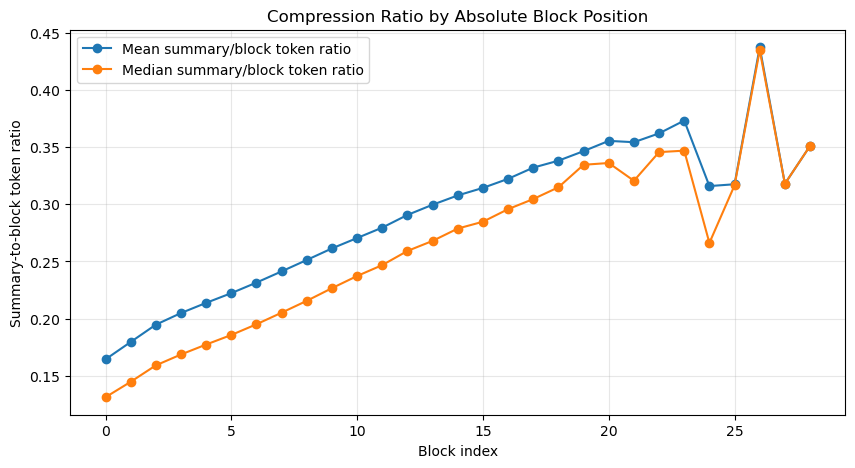

In [175]:
plt.figure(figsize=(10, 5))

plt.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["mean_ratio"],
    marker="o",
    label="Mean summary/block token ratio",
)

plt.plot(
    compression_by_block_index["block_index"],
    compression_by_block_index["median_ratio"],
    marker="o",
    label="Median summary/block token ratio",
)

plt.xlabel("Block index")
plt.ylabel("Summary-to-block token ratio")
plt.title("Compression Ratio by Absolute Block Position")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [176]:
df_model_blocks = df_model_blocks.copy()

df_model_blocks["relative_position_bin"] = pd.cut(
    df_model_blocks["relative_block_position"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

In [177]:
compression_by_relative_position = (
    df_model_blocks
    .groupby("relative_position_bin", observed=True)
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        median_ratio=("summary_to_block_token_ratio", "median"),
        mean_savings=("token_compression_savings", "mean"),
        median_savings=("token_compression_savings", "median"),
    )
    .reset_index()
)

compression_by_relative_position.round(4)

,relative_position_bin,n_blocks,mean_ratio,median_ratio,mean_savings,median_savings
0,"(-0.001, 0.1]",288524,0.1678,0.1358,0.8322,0.8642
1,"(0.1, 0.2]",206026,0.1795,0.1467,0.8205,0.8533
2,"(0.2, 0.3]",168741,0.1975,0.1644,0.8025,0.8356
3,"(0.3, 0.4]",187115,0.2079,0.1736,0.7921,0.8264
4,"(0.4, 0.5]",213684,0.2171,0.1820,0.7829,0.8180
5,"(0.5, 0.6]",143965,0.2258,0.1911,0.7742,0.8089
6,"(0.6, 0.7]",162970,0.2363,0.2007,0.7637,0.7993
7,"(0.7, 0.8]",192886,0.2395,0.2028,0.7605,0.7972
8,"(0.8, 0.9]",181881,0.2455,0.2072,0.7545,0.7928
9,"(0.9, 1.0]",267718,0.2532,0.2143,0.7468,0.7857


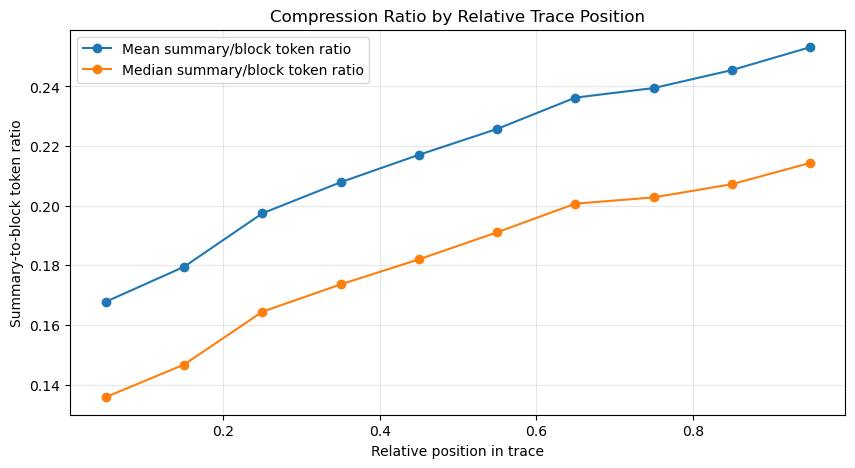

In [178]:
compression_by_relative_position["position_midpoint"] = (
    compression_by_relative_position["relative_position_bin"]
    .apply(lambda interval: interval.mid)
    .astype(float)
)

plt.figure(figsize=(10, 5))

plt.plot(
    compression_by_relative_position["position_midpoint"],
    compression_by_relative_position["mean_ratio"],
    marker="o",
    label="Mean summary/block token ratio",
)

plt.plot(
    compression_by_relative_position["position_midpoint"],
    compression_by_relative_position["median_ratio"],
    marker="o",
    label="Median summary/block token ratio",
)

plt.xlabel("Relative position in trace")
plt.ylabel("Summary-to-block token ratio")
plt.title("Compression Ratio by Relative Trace Position")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [179]:
compression_by_relative_position = (
    df_model_blocks
    .groupby("relative_position_bin", observed=True)
    .agg(
        n_blocks=("summary_to_block_token_ratio", "size"),
        mean_ratio=("summary_to_block_token_ratio", "mean"),
        std_ratio=("summary_to_block_token_ratio", "std"),
        median_ratio=("summary_to_block_token_ratio", "median"),
    )
    .reset_index()
)

compression_by_relative_position["se_ratio"] = (
    compression_by_relative_position["std_ratio"]
    / np.sqrt(compression_by_relative_position["n_blocks"])
)

compression_by_relative_position["position_midpoint"] = (
    compression_by_relative_position["relative_position_bin"]
    .apply(lambda interval: interval.mid)
    .astype(float)
)

## Compression Evolution Interpretation

Both position-based plots suggest that compression changes systematically over the reasoning trace.

The mean `summary_to_block_token_ratio` is lower near the beginning of traces, around 0.17 for the first block or lowest relative-position bins. It increases toward the end of traces, reaching roughly 0.25 near relative position 1. Because lower ratios indicate stronger compression, this suggests that earlier reasoning blocks tend to be compressed more aggressively than later blocks.

The relative-position plot shows the clearest trend because it normalizes traces of different lengths onto a common 0-to-1 scale. This makes early, middle, and late trace phases comparable across examples.

The absolute block-index plot is more erratic at higher block indices. This is expected because fewer traces contain many blocks, so estimates for later absolute positions are based on fewer observations and are more sensitive to sample variation.

Substantively, the upward trend may indicate that early reasoning blocks contain more exploratory or redundant material, while later blocks become more concise, answer-directed, or less compressible.

This pattern supports the need for sequential features. If compression behavior changes over the reasoning trajectory, then models should account not only for the current block but also for where the block occurs within the trace and what has happened in previous blocks.

## Sequential Block-Level Compression Modeling

This section models compression as an online block-level prediction problem.

For each block `t`, the target is whether the corresponding summary `summary_t` is highly compressed. Predictors include the original problem, metadata, the current block, and compression history from previous blocks in the same trace.

Lagged and cumulative features are shifted so that the current summary is not used to predict itself. This prevents target leakage while allowing the model to use the observed compression trajectory up to the previous step.

In [180]:
# sort by trace and block
df_seq = df_model_blocks.sort_values(["trace_id", "block_index"]).copy()

In [181]:
# previous compression behavior within the same trace.
df_seq["prev_summary_to_block_token_ratio"] = (
    df_seq.groupby("trace_id")["summary_to_block_token_ratio"].shift(1)
)

df_seq["prev_token_compression_savings"] = (
    df_seq.groupby("trace_id")["token_compression_savings"].shift(1)
)

df_seq["prev_block_tokens"] = (
    df_seq.groupby("trace_id")["block_tokens"].shift(1)
)

df_seq["prev_summary_tokens"] = (
    df_seq.groupby("trace_id")["summary_tokens"].shift(1)
)

In [182]:
# Cumulative token history before the current block. shift(1) prevents leakage
# from the current summary into current-row predictors.
df_seq["cum_block_tokens_before_t"] = (
    df_seq.groupby("trace_id")["block_tokens"].cumsum()
    - df_seq["block_tokens"]
)

df_seq["cum_summary_tokens_before_t"] = (
    df_seq.groupby("trace_id")["summary_tokens"].cumsum()
    - df_seq["summary_tokens"]
)

df_seq["cum_compression_ratio_before_t"] = (
    df_seq["cum_summary_tokens_before_t"]
    / df_seq["cum_block_tokens_before_t"]
).replace([np.inf, -np.inf], np.nan)

In [183]:
# Expanding mean of prior compression ratios only. shift(1) ensures the current
# summary ratio is not used to predict itself.
df_seq["mean_prev_summary_to_block_ratio"] = (
    df_seq
    .groupby("trace_id")["summary_to_block_token_ratio"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

In [184]:
# First blocks have no previous history. Use explicit zero fills plus an indicator
# so the model can distinguish "no history yet" from true zero-valued history.
df_seq["has_previous_block"] = (df_seq["block_index"] > 0).astype(int)

history_features = [
    "prev_summary_to_block_token_ratio",
    "prev_token_compression_savings",
    "prev_block_tokens",
    "prev_summary_tokens",
    "cum_block_tokens_before_t",
    "cum_summary_tokens_before_t",
    "cum_compression_ratio_before_t",
    "mean_prev_summary_to_block_ratio",
]

df_seq[history_features] = df_seq[history_features].fillna(0)

In [185]:
seq_numeric_features = [
    "block_index",
    "problem_chars",
    "problem_tokens",
    "problem_math_symbol_share",
    "problem_question_mark_count",
    "block_chars",
    "block_tokens",
    "prev_summary_to_block_token_ratio",
    "prev_token_compression_savings",
    "prev_block_tokens",
    "prev_summary_tokens",
    "cum_block_tokens_before_t",
    "cum_summary_tokens_before_t",
    "cum_compression_ratio_before_t",
    "mean_prev_summary_to_block_ratio",
]

seq_binary_features = [
    "problem_has_multiple_choice",
    "problem_has_code_fence",
    "has_previous_block",
]

seq_categorical_features = [
    "domain",
    "source",
    "difficulty",
]

seq_feature_columns = (
    seq_numeric_features
    + seq_binary_features
    + seq_categorical_features
)

In [186]:
df_model_seq = df_seq[
    seq_feature_columns + [TARGET, GROUP_COL, SPLIT_COL]
].dropna().copy()

X_seq = df_model_seq[seq_feature_columns]
y_seq = df_model_seq[TARGET]
groups_seq = df_model_seq[GROUP_COL]
seq_model_split = df_model_seq[SPLIT_COL]

In [187]:
seq_train_mask = seq_model_split == "train"
seq_test_mask = seq_model_split == "test"

X_seq_train = X_seq.loc[seq_train_mask]
X_seq_test = X_seq.loc[seq_test_mask]
y_seq_train = y_seq.loc[seq_train_mask]
y_seq_test = y_seq.loc[seq_test_mask]

In [188]:
seq_tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", seq_numeric_features),
        ("bin", "passthrough", seq_binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), seq_categorical_features),
    ]
)

In [189]:
seq_rf_model = Pipeline(
    steps=[
        ("preprocess", seq_tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

seq_rf_model.fit(X_seq_train, y_seq_train)

seq_rf_metrics = evaluate_classifier(seq_rf_model, X_seq_test, y_seq_test)
format_metrics_percent(seq_rf_metrics)

,metric,value
0,accuracy,75.39%
1,balanced_accuracy,72.38%
2,roc_auc,81.15%


In [190]:
seq_gb_model = Pipeline(
    steps=[
        ("preprocess", seq_tree_preprocess),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

seq_gb_model.fit(X_seq_train, y_seq_train)

seq_gb_metrics = evaluate_classifier(seq_gb_model, X_seq_test, y_seq_test)
format_metrics_percent(seq_gb_metrics)

,metric,value
0,accuracy,72.35%
1,balanced_accuracy,73.15%
2,roc_auc,81.35%


## Sequential Feature Importance Diagnostics

This section checks whether the sequential history features are actually used by the models.

The random forest exposes impurity-based feature importances directly. These importances are useful for a first diagnostic, but they can be biased toward continuous variables and should be interpreted cautiously.

For gradient boosting, we use permutation importance on a test subset. Permutation importance measures how much model performance drops when a feature is randomly shuffled, making it a more direct estimate of predictive contribution.

In [191]:
from sklearn.inspection import permutation_importance

In [192]:
# Recover feature names after preprocessing so importances can be mapped back
# to the original sequential feature set.
seq_rf_feature_names = (
    seq_rf_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

seq_rf_importance_table = (
    pd.DataFrame({
        "feature": seq_rf_feature_names,
        "importance": seq_rf_model.named_steps["model"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

seq_rf_importance_table.head(30).round(4)

,feature,importance
6,num__block_tokens,0.2399
5,num__block_chars,0.2018
13,num__cum_compression_ratio_before_t,0.0592
14,num__mean_prev_summary_to_block_ratio,0.0555
12,num__cum_summary_tokens_before_t,0.0496
7,num__prev_summary_to_block_token_ratio,0.0464
11,num__cum_block_tokens_before_t,0.0446
1,num__problem_chars,0.0433
9,num__prev_block_tokens,0.0419
10,num__prev_summary_tokens,0.0411


In [193]:
def assign_seq_feature_family(feature: str) -> str:
    # Group transformed feature names into interpretable families.
    if feature.startswith("num__prev") or feature.startswith("num__cum") or "mean_prev" in feature:
        return "history"
    if "block_tokens" in feature or "block_chars" in feature or "block_index" in feature:
        return "current_block"
    if "problem" in feature:
        return "problem"
    if feature.startswith("cat__"):
        return "metadata"
    if feature.startswith("bin__"):
        return "binary_problem_or_history"
    return "other"

In [194]:
seq_rf_importance_by_family = (
    seq_rf_importance_table
    .assign(feature_family=lambda df: df["feature"].map(assign_seq_feature_family))
    .groupby("feature_family", as_index=False)
    .agg(total_importance=("importance", "sum"))
    .sort_values("total_importance", ascending=False)
)

seq_rf_importance_by_family.round(4)

,feature_family,total_importance
1,current_block,0.4648
2,history,0.3774
4,problem,0.1320
3,metadata,0.0245
0,binary_problem_or_history,0.0012


## Sequential Random Forest Feature Families

The random forest feature-family diagnostic shows that current-block features remain the largest source of predictive signal, accounting for about 47% of total impurity-based importance.

However, history features account for about 37% of total importance. This is substantial and suggests that previous compression behavior and cumulative trace state are important for predicting the compressibility of the current block.

Problem-derived features account for about 14% of total importance, while metadata contributes relatively little in this sequential setup.

This supports the sequential modeling hypothesis: compression is not only a property of the current block, but also depends on the prior trajectory of the reasoning trace.

In [195]:
# Use a manageable test subset because permutation importance repeatedly scores
# the model after shuffling each feature.
PERMUTATION_SAMPLE_SIZE = 50_000

if len(X_seq_test) > PERMUTATION_SAMPLE_SIZE:
    X_perm = X_seq_test.sample(PERMUTATION_SAMPLE_SIZE, random_state=42)
    y_perm = y_seq_test.loc[X_perm.index]
else:
    X_perm = X_seq_test
    y_perm = y_seq_test

X_perm.shape

(50000, 21)

In [197]:
# Permutation importance estimates how much ROC AUC decreases when each
# original input column is shuffled.
seq_gb_permutation = permutation_importance(
    seq_gb_model,
    X_perm,
    y_perm,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [198]:
seq_gb_permutation_table = (
    pd.DataFrame({
        "feature": X_perm.columns,
        "importance_mean": seq_gb_permutation.importances_mean,
        "importance_std": seq_gb_permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

seq_gb_permutation_table.round(4)

,feature,importance_mean,importance_std
6,block_tokens,0.2578,0.0016
12,cum_summary_tokens_before_t,0.0321,0.0009
0,block_index,0.0075,0.0004
5,block_chars,0.0049,0.0005
10,prev_summary_tokens,0.0044,0.0002
19,source,0.0033,0.0002
11,cum_block_tokens_before_t,0.0026,0.0002
8,prev_token_compression_savings,0.0012,0.0002
2,problem_tokens,0.0011,0.0002
3,problem_math_symbol_share,0.0008,0.0001


In [199]:
def assign_original_seq_feature_family(feature: str) -> str:
    # Group original dataframe columns into interpretable feature families.
    if feature.startswith("prev_") or feature.startswith("cum_") or feature.startswith("mean_prev"):
        return "history"
    if feature in {"block_index", "block_chars", "block_tokens"}:
        return "current_block"
    if feature.startswith("problem_"):
        return "problem"
    if feature in {"domain", "source", "difficulty"}:
        return "metadata"
    if feature == "has_previous_block":
        return "history"
    return "other"

In [200]:
seq_gb_permutation_by_family = (
    seq_gb_permutation_table
    .assign(feature_family=lambda df: df["feature"].map(assign_original_seq_feature_family))
    .groupby("feature_family", as_index=False)
    .agg(total_importance=("importance_mean", "sum"))
    .sort_values("total_importance", ascending=False)
)

seq_gb_permutation_by_family.round(4)

# not normalized to sum to 1
# measures absolute score performance drop
# approximate loss in ROC AUC when that feature family is altered

,feature_family,total_importance
0,current_block,0.2702
1,history,0.0417
2,metadata,0.0042
3,problem,0.0024


## Sequential Gradient Boosting Permutation Importance

The gradient boosting permutation diagnostic gives a different perspective from the random forest impurity importances.

For gradient boosting, current-block features dominate the predictive signal. Shuffling current-block features produces the largest drop in ROC AUC, while shuffling history features has a much smaller effect. Problem features and metadata contribute very little incremental predictive value in this diagnostic.

This suggests that, for the gradient boosting model, most of the useful information for predicting current summary compression is contained in the current block itself, especially its token/length characteristics. The prior compression trajectory provides some additional signal, but it is much weaker than the current-block signal.

The contrast with the random forest importance table is informative. Random forest impurity importances assign substantial importance to history features, but permutation importance for gradient boosting suggests that those history features may be partly redundant with current-block features or less critical for out-of-sample ranking performance.

# Synoptic Model Comparison

This table summarizes all modeling tasks run so far.

The block-level models predict compression for individual block-summary pairs. The trace-level models predict whether an entire reasoning trace is highly compressible using only problem-level information. The sequential models use progressively richer information about the reasoning process, including the current block and, in the full sequential setup, prior compression history.

Balanced accuracy and ROC AUC are the main comparison metrics because the compression targets are imbalanced.

In [201]:
all_model_results = pd.DataFrame([
    {
        "task": "Block-level",
        "feature_set": "Current block + problem + metadata",
        "model": "Dummy",
        **dummy_metrics,
    },
    {
        "task": "Block-level",
        "feature_set": "Current block + problem + metadata",
        "model": "Logistic regression",
        **logit_metrics,
    },
    {
        "task": "Block-level",
        "feature_set": "Current block + problem + metadata",
        "model": "Random forest validation-tuned",
        **rf_validation_tuned_metrics,
    },
    {
        "task": "Block-level",
        "feature_set": "Current block + problem + metadata",
        "model": "Gradient boosting",
        **gb_metrics,
    },
    {
        "task": "Trace-level",
        "feature_set": "Problem + metadata only",
        "model": "Dummy",
        **trace_dummy_metrics,
    },
    {
        "task": "Trace-level",
        "feature_set": "Problem + metadata only",
        "model": "Logistic regression",
        **trace_logit_metrics,
    },
    {
        "task": "Trace-level",
        "feature_set": "Problem + metadata only",
        "model": "Random forest",
        **trace_rf_metrics,
    },
    {
        "task": "Trace-level",
        "feature_set": "Problem + metadata only",
        "model": "Gradient boosting",
        **trace_gb_metrics,
    },
    {
        "task": "First-block sequential",
        "feature_set": "Problem + first block + metadata",
        "model": "Random forest",
        **first_rf_metrics,
    },
    {
        "task": "First-block sequential",
        "feature_set": "Problem + first block + metadata",
        "model": "Gradient boosting",
        **first_gb_metrics,
    },
    {
        "task": "Sequential block-level",
        "feature_set": "Problem + current block + prior history + metadata",
        "model": "Random forest",
        **seq_rf_metrics,
    },
    {
        "task": "Sequential block-level",
        "feature_set": "Problem + current block + prior history + metadata",
        "model": "Gradient boosting",
        **seq_gb_metrics,
    },
])

In [202]:
all_model_results_display = all_model_results.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    all_model_results_display[col] = (
        all_model_results_display[col] * 100
    ).round(2)

all_model_results_display

,task,feature_set,model,accuracy,balanced_accuracy,roc_auc
0,Block-level,Current block + problem + metadata,Dummy,75.03,50.00,NaN
1,Block-level,Current block + problem + metadata,Logistic regression,73.28,71.86,79.70
2,Block-level,Current block + problem + metadata,Random forest validation-tuned,73.65,72.22,80.37
3,Block-level,Current block + problem + metadata,Gradient boosting,71.86,72.73,80.92
4,Trace-level,Problem + metadata only,Dummy,75.12,50.00,NaN
5,Trace-level,Problem + metadata only,Logistic regression,51.72,58.37,59.46
6,Trace-level,Problem + metadata only,Random forest,61.12,62.84,68.48
7,Trace-level,Problem + metadata only,Gradient boosting,52.91,60.62,64.39
8,First-block sequential,Problem + first block + metadata,Random forest,74.76,75.56,84.23
9,First-block sequential,Problem + first block + metadata,Gradient boosting,74.73,75.79,84.37


In [203]:
all_model_results = pd.DataFrame([
    {"task": "Block-level", "feature_set": "Current block + problem + metadata", "model": "Dummy", **dummy_metrics},
    {"task": "Block-level", "feature_set": "Current block + problem + metadata", "model": "Logistic regression", **logit_metrics},
    {"task": "Block-level", "feature_set": "Current block + problem + metadata", "model": "Random forest validation-tuned", **rf_validation_tuned_metrics},
    {"task": "Block-level", "feature_set": "Current block + problem + metadata", "model": "Gradient boosting", **gb_metrics},
    {"task": "Trace-level", "feature_set": "Problem + metadata only", "model": "Dummy", **trace_dummy_metrics},
    {"task": "Trace-level", "feature_set": "Problem + metadata only", "model": "Logistic regression", **trace_logit_metrics},
    {"task": "Trace-level", "feature_set": "Problem + metadata only", "model": "Random forest", **trace_rf_metrics},
    {"task": "Trace-level", "feature_set": "Problem + metadata only", "model": "Gradient boosting", **trace_gb_metrics},
    {"task": "First-block sequential", "feature_set": "Problem + first block + metadata", "model": "Random forest", **first_rf_metrics},
    {"task": "First-block sequential", "feature_set": "Problem + first block + metadata", "model": "Gradient boosting", **first_gb_metrics},
    {"task": "Sequential block-level", "feature_set": "Problem + current block + prior history + metadata", "model": "Random forest", **seq_rf_metrics},
    {"task": "Sequential block-level", "feature_set": "Problem + current block + prior history + metadata", "model": "Gradient boosting", **seq_gb_metrics},
])

for metric in ["accuracy", "balanced_accuracy", "roc_auc"]:
    if metric not in all_model_results.columns:
        all_model_results[metric] = np.nan

all_model_results_display = all_model_results.copy()

for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    all_model_results_display[col] = (
        all_model_results_display[col] * 100
    ).round(2)

all_model_results_display

,task,feature_set,model,accuracy,balanced_accuracy,roc_auc
0,Block-level,Current block + problem + metadata,Dummy,75.03,50.00,NaN
1,Block-level,Current block + problem + metadata,Logistic regression,73.28,71.86,79.70
2,Block-level,Current block + problem + metadata,Random forest validation-tuned,73.65,72.22,80.37
3,Block-level,Current block + problem + metadata,Gradient boosting,71.86,72.73,80.92
4,Trace-level,Problem + metadata only,Dummy,75.12,50.00,NaN
5,Trace-level,Problem + metadata only,Logistic regression,51.72,58.37,59.46
6,Trace-level,Problem + metadata only,Random forest,61.12,62.84,68.48
7,Trace-level,Problem + metadata only,Gradient boosting,52.91,60.62,64.39
8,First-block sequential,Problem + first block + metadata,Random forest,74.76,75.56,84.23
9,First-block sequential,Problem + first block + metadata,Gradient boosting,74.73,75.79,84.37


1. Core Modeling Insight
The strongest result is that compressibility is predictable once the reasoning block is observed.

Problem-only trace-level models are weak:

best trace-level ROC AUC ≈ 67.5
But block-level and first-block models are much stronger:

block-level ROC AUC ≈ 80-81
first-block ROC AUC ≈ 82
sequential block ROC AUC ≈ 81
So the original problem alone does not strongly determine compressibility. The generated reasoning text itself contains the main signal.

That matters. It suggests that compressibility is less a fixed property of the prompt and more an emergent property of the model’s reasoning trajectory.

A second insight: simple models are surprisingly competitive. Logistic regression reaches:

ROC AUC ≈ 79.8
balanced accuracy ≈ 72.2
close to tree ensembles. That implies a large part of the signal is carried by relatively simple structural variables, especially block length and position, not only complex nonlinear interactions.

A third insight: sequential history helps, but only modestly. The current block dominates. Prior compression trajectory adds some signal, especially in random forest diagnostics, but the performance gain is small. This suggests the immediate local structure of reasoning is more predictive than long-range history, at least with the features currently engineered.


2. Compression, Prediction, And Intelligence
At a deeper level, your results touch a classic idea: prediction and compression are tightly linked.

A system can compress something when it can exploit regularities in it. If a reasoning block is highly compressible, it contains structure: repetition, redundancy, intermediate scaffolding, or predictable transitions. If it is hard to compress, it may contain dense information, irreducible details, or noise-like variation.

This connects to intelligence because intelligent systems often work by finding useful structure:

structure -> prediction -> compression
If a model can predict what parts of a reasoning trace are redundant or summarizable, it is identifying regularities in the reasoning process. In that sense, compressibility becomes a proxy for how much of the reasoning is systematic rather than accidental.

Your findings suggest that LLM reasoning traces are not random streams. If they were close to random noise, compression class would be difficult to predict. But models reach ROC AUC around 80, which means there is substantial regularity in how reasoning blocks become summaries.

The incompressibility of random noise is the opposite pole. A random sequence has no exploitable pattern; the best compressed version is roughly as long as the original. In your dataset, the summaries are often much shorter than blocks, and their compression behavior is predictable. That implies the reasoning traces have systematic redundancy.

The most interesting philosophical reading is this:

Reasoning traces may contain both information-bearing steps and compressible cognitive scaffolding.
The scaffolding helps generation proceed, but not all of it is needed to preserve state. MEMENTO’s premise sits exactly there: long reasoning can be converted into compressed state without fully losing forward usefulness.

So your empirical result supports a middle position:

CoT is not meaningless verbosity.
CoT is also not maximally dense information.
It contains structured redundancy that can often be predicted and compressed.
That is a useful research framing. The next question is not merely:

Can we compress reasoning?
but:

Which parts of reasoning are compressible scaffolding, and which parts are irreducible state?

### Store data for later reuse

In [ ]:
all_model_results.to_parquet(
    FULL_BUILD_DIR / "model_results_summary.parquet",
    index=False,
)
seq_rf_importance_by_family.to_parquet(
    FULL_BUILD_DIR / "seq_rf_importance_by_family.parquet",
    index=False,
)
seq_gb_permutation_by_family.to_parquet(
    FULL_BUILD_DIR / "seq_gb_permutation_by_family.parquet",
    index=False,
)

In [ ]:
pd.read_parquet(FULL_BUILD_DIR / "model_results_summary.parquet").shape